# 10.4.1 传感器位置与能观矩阵

## 学习目标与先修知识

计算能观矩阵（matrix），识别无法从读数恢复的状态（state）方向。

先修：第7.1章能观性（observability）与观测（observation）映射、10.3能控性（controllability）。

## 具体问题

执行器能改变全部状态，并不意味着一只传感器能看到全部状态。把传感器从第一状态移到第二状态后，哪些初态差异永远不会出现在读数里？

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

仍用双积分矩阵 A=[[0,1],[0,0]]，分别手算C=[1,0]和C=[0,1]的CA。

In [2]:
A=np.array([[0.,1.],[0.,0.]]);print("C1 A, C2 A:",(np.array([1.,0.])@A).tolist(),(np.array([0.,1.])@A).tolist())

C1 A, C2 A: [0.0, 1.0] [0.0, 0.0]


## 模型假设

已知连续二维线性模型（model） $\dot x=Ax+Bu$ 和输入（input），初态未知。读数 $y=Cx$ 暂时无噪；传感器C的方向和单位明确。能观性只判断已知参数（parameter）模型中的状态可恢复性，不证明模型参数本身可以由这些读数辨识。

## 数学解释与推导

先看读数 $y=Cx$；无输入时，它的变化率是 $\dot y=CAx$。若输入已知，可从 $\dot y=CAx+CBu$ 扣除 $CBu$。读数与其变化率能否区分所有初态，由二维能观矩阵判断：
$$\mathcal O=\begin{bmatrix}C\\CA\end{bmatrix}.$$
若秩（rank）为2，两个独立方向的初态信息可从理想读数序列中恢复。对本节A，$C_1=[1,0]$ 给 $CA=[0,1]$，满秩；$C_2=[0,1]$ 给 $CA=[0,0]$，第一状态对所有读数不可见。动态方向不能反向猜测：第二状态会推动第一状态，但第一状态不会推动第二状态。

若读数含噪，满秩并不保证任意短窗中估计精确；还要考虑误差放大、采样（sampling）和传感器失效。控制器只能使用可见读数和由它构造的估计，不能暗用教学模拟中的隐藏真值。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def observability_2d(A, C):
    CA = [C[0] * A[0][j] + C[1] * A[1][j] for j in range(2)]
    matrix = [[C[0], C[1]], CA]
    determinant = matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]
    return matrix, determinant

## 对照实验

给两个不同的初态，但使其第二状态相同。画两种传感器配置的读数；观察哪一配置能看到初态第一分量的差异。

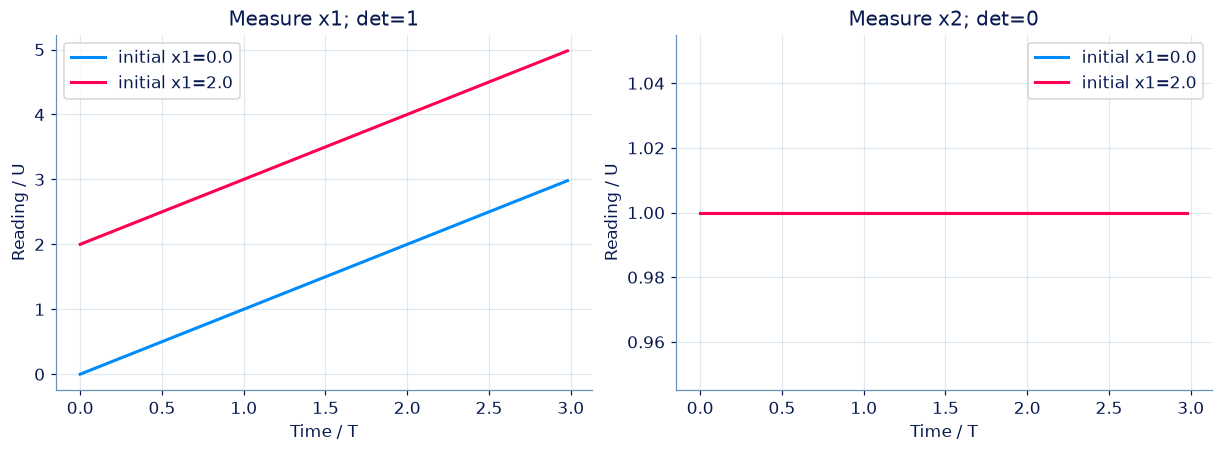

In [4]:
A=np.array([[0.,1.],[0.,0.]]);h=.02;steps=150
starts=[np.array([0.,1.]),np.array([2.,1.])]
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,C,label in zip(axes,[[1.,0.],[0.,1.]],['Measure x1','Measure x2']):
    O,det=observability_2d(A.tolist(),C)
    for x0,color in zip(starts,[BLUE,PINK]):
        x=x0.copy();readings=[]
        for _ in range(steps):
            readings.append(float(np.array(C)@x));x=x+h*A@x
        ax.plot(np.arange(steps)*h,readings,label=f'initial x1={x0[0]}',color=color)
    ax.set(xlabel='Time / T',ylabel='Reading / U',title=f'{label}; det={det:g}');ax.legend()
plt.show()

## 结果解释

测x₁时两条读数从不同位置出发，差异可见；只测x₂时两条读数完全重合，第一状态差异没有进入读数。图只覆盖这两个初态的反例，满秩与不满秩的结构性判断来自能观矩阵。

### 独立核对

独立以矩阵秩检查两种传感器，并直接验证C₂ A 的第一列为0，避免只凭叠合图判断。

In [5]:
for C,expected in [([1.,0.],2),([0.,1.],1)]:
    O,det=observability_2d(A.tolist(),C)
    assert np.linalg.matrix_rank(np.array(O))==expected
np.testing.assert_allclose(np.array([0.,1.])@A,[0,0])
print('能观秩与不可见方向独立核对。')

能观秩与不可见方向独立核对。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：二维能观矩阵

已知二维线性模型（model）与单个测量 y=Cx。计算纵向堆叠的 [C;CA] 及其行列式（determinant）；按题给数值尺度，|det|>1e−10 判为满秩（rank）。

**函数与代码模板**

```python
def solve(
    A: list[list[float]],
    C: list[float],
) -> tuple[list[list[float]], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A` | `list[list[float]]` | 2×2 状态（state）矩阵（matrix）。 | 按状态定义 |
| `C` | `list[float]` | 长度2的测量行向量（vector）。 | 按观测/状态定义 |

**返回值**

按以下顺序返回元组：(matrix, determinant)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 两行分别为C与CA。 | 按测量定义 |
| `determinant` | `float` | 能观矩阵行列式。 | 组合单位 |

**计算规则**

CA_j=Σ_i C_i A_ij；将C、CA作为两行，计算ad−bc。

**约束与边界**

- 输入（input）均为有限数；只需实现题定模型，不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A | 2×2 状态（state）矩阵（matrix）。 | [[0.0, 1.0], [0.0, 0.0]] | 按状态定义 |
| C | 长度2的测量行向量（vector）。 | [1.0, 0.0] | 按观测/状态定义 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A = [[0.0, 1.0], [0.0, 0.0]]
C = [1.0, 0.0]

result = solve(A, C)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 两行分别为C与CA。 | [[1.0, 0.0], [0.0, 1.0]] | 按测量定义 |
| determinant | 能观矩阵行列式。 | 1 | 组合单位 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1.0, 0.0], [0.0, 1.0]], 1.0)
```

**样例解释**

测第一状态 C=[1,0] 时未来读数包含第二状态；只测第二状态 C=[0,1] 则第一状态不可恢复。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：二维能观矩阵](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-observability-two)

### 第 2 题 · 单项选择题：换一个传感器

A=[[0,1],[0,0]]。若只测 x₂，与只测 x₁ 相比，哪项判断成立？

- **A.** 只测x₁在本模型（model）下可观；只测x₂无法恢复x₁。
- **B.** 只测x₂一定可恢复x₁，因为两个状态（state）耦合。
- **C.** 能观性（observability）和传感器位置无关。
- **D.** 能观性直接说明未知参数（parameter）也可辨识。

[作答：换一个传感器](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-sensor-position)

### 第 3 题 · 单项选择题：观测器需要知道输入吗

线性模型（model） x_next=Ax+Bu、y=Cx，估计器使用同一模型。为什么输入（input） u 必须作为已知量接入？

- **A.** 否则读数变化中的输入作用可能被误认为状态（state）变化。
- **B.** 因为输入是传感器噪声的别名。
- **C.** 观测（observation）器不需要模型A。
- **D.** 已知输入保证测量无噪声。

[作答：观测器需要知道输入吗](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-known-input)

### 第 4 题 · 单项选择题：可观不等于精确恢复

(A,C) 满秩（rank）可观，实际读数含噪。下列哪项正确？

- **A.** 满秩是理想已知模型（model）的结构条件，噪声下仍需讨论估计误差。
- **B.** 满秩保证每次单独读数直接给出全部状态（state）。
- **C.** 满秩保证任何初始误差一步归零。
- **D.** 满秩自动证明参数（parameter）源于真实生理机制。

[作答：可观不等于精确恢复](http://127.0.0.1:8000/chapters/10-04-%E7%8A%B6%E6%80%81%E8%A7%82%E6%B5%8B%E5%99%A8%E4%B8%8E%E8%BE%93%E5%87%BA%E5%8F%8D%E9%A6%88/practice/?question=p10-observability-vs-noise)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。